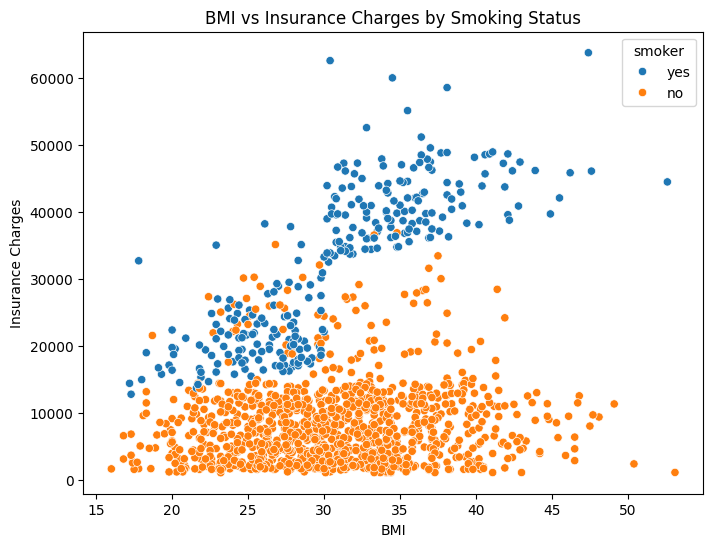

X_train_processed shape: (1070, 11)
X_test_processed shape: (268, 11)
Linear Regression model trained successfully.
MAE : 4181.561524000791
MSE : 33600065.35507783
RMSE: 5796.556335884076
R2 Score: 0.7835726930039905


['preprocessor.pkl']

In [29]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

# Paste your copied raw GitHub URL here
dataset_url = 'https://raw.githubusercontent.com/MAANYA358/Medical-Insurance-Cost-Prediction/refs/heads/main/insurance_dataset.csv'

# Load the data into a pandas DataFrame
df = pd.read_csv(dataset_url)

# Display the first 5 rows to confirm it loaded correctly
#print(df.shape)
# print(df.head)
#df.isnull().sum()

# df[df.duplicated()]
# df = df.drop_duplicates()
# df.duplicated().sum()
# df.shape

plt.figure(figsize=(8,6))

sns.scatterplot(
    x='bmi',
    y='expenses',
    hue='smoker',
    data=df
)

plt.title("BMI vs Insurance Charges by Smoking Status")
plt.xlabel("BMI")
plt.ylabel("Insurance Charges")

plt.show()

#Features and Target
X = df.drop('expenses', axis=1)
y = df['expenses']

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include='object').columns
numerical_cols = X.select_dtypes(exclude='object').columns

# Define preprocessing steps
# One-hot encode categorical features
# Standard scale numerical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

# Create a preprocessing pipeline that includes feature scaling and encoding
# The final model will be added after the train-test split for clarity

# Train-Test Split (before full preprocessing pipeline for cleaner split)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Apply preprocessing separately to train and test sets
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"X_train_processed shape: {X_train_processed.shape}")
print(f"X_test_processed shape: {X_test_processed.shape}")

#Train the Model
model = LinearRegression()
model.fit(X_train_processed, y_train)

print("Linear Regression model trained successfully.")

#Prediction
y_pred = model.predict(X_test_processed)

#Evaluation
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

#Save the Model
joblib.dump(model, "insurance_model.pkl")
joblib.dump(preprocessor, "preprocessor.pkl") # Save the preprocessor as well